In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import mplcyberpunk
from binance.client import Client
from datetime import datetime, timedelta

from utils import trading_utils

plt.style.use("cyberpunk")

### Inicializar cliente Binance (você precisará adicionar suas chaves API)


In [2]:
# Inicializar cliente Binance (você precisará adicionar suas chaves API)
client = Client()

### # Definir parâmetros


In [3]:
symbol = 'BTCUSDT'
interval = Client.KLINE_INTERVAL_30MINUTE
days_interval = 30

"""
KLINE_INTERVAL_1MINUTE - 1 minuto
KLINE_INTERVAL_3MINUTE - 3 minutos
KLINE_INTERVAL_5MINUTE - 5 minutos
KLINE_INTERVAL_15MINUTE - 15 minutos
KLINE_INTERVAL_30MINUTE - 30 minutos
KLINE_INTERVAL_1HOUR - 1 hora
KLINE_INTERVAL_2HOUR - 2 horas
KLINE_INTERVAL_4HOUR - 4 horas
KLINE_INTERVAL_6HOUR - 6 horas
KLINE_INTERVAL_8HOUR - 8 horas
KLINE_INTERVAL_12HOUR - 12 horas
KLINE_INTERVAL_1DAY - 1 dia
KLINE_INTERVAL_3DAY - 3 dias
KLINE_INTERVAL_1WEEK - 1 semana
KLINE_INTERVAL_1MONTH - 1 mês
"""


'\nKLINE_INTERVAL_1MINUTE - 1 minuto\nKLINE_INTERVAL_3MINUTE - 3 minutos\nKLINE_INTERVAL_5MINUTE - 5 minutos\nKLINE_INTERVAL_15MINUTE - 15 minutos\nKLINE_INTERVAL_30MINUTE - 30 minutos\nKLINE_INTERVAL_1HOUR - 1 hora\nKLINE_INTERVAL_2HOUR - 2 horas\nKLINE_INTERVAL_4HOUR - 4 horas\nKLINE_INTERVAL_6HOUR - 6 horas\nKLINE_INTERVAL_8HOUR - 8 horas\nKLINE_INTERVAL_12HOUR - 12 horas\nKLINE_INTERVAL_1DAY - 1 dia\nKLINE_INTERVAL_3DAY - 3 dias\nKLINE_INTERVAL_1WEEK - 1 semana\nKLINE_INTERVAL_1MONTH - 1 mês\n'

### # Obter dados históricos


In [4]:
# Obter dados historicos de preco

dados_historicos = client.futures_historical_klines(
    symbol,
    interval,
    str((datetime.now() - timedelta(days=days_interval)).strftime("%d %b %Y %H:%M:%S")),
    str(datetime.now().strftime("%d %b %Y %H:%M:%S"))
)

# Obter dados de open interest (limitando a 30 dias devido a restrições da API)
open_interest = client.futures_open_interest_hist(
    symbol=symbol,
    period=interval,
    limit=500,
    startTime=int((datetime.now() - timedelta(days=days_interval)).timestamp() * 1000),
    endTime=int(datetime.now().timestamp() * 1000)
)



In [5]:
# Obter dados historicos de preco

dados_historicos = client.get_historical_klines(
    symbol,
    interval,
    str((datetime.now() - timedelta(days=days_interval)).strftime("%d %b %Y %H:%M:%S")),
    str(datetime.now().strftime("%d %b %Y %H:%M:%S"))
)

# Obter dados de open interest (limitando a 30 dias devido a restrições da API)
open_interest = client.futures_open_interest_hist(
    symbol=symbol,
    period=interval,
    limit=500,
    startTime=int((datetime.now() - timedelta(days=days_interval)).timestamp() * 1000),
    endTime=int(datetime.now().timestamp() * 1000)
)



In [6]:
# Converter para DataFrame

dados_historicos = pd.DataFrame(dados_historicos, columns=[ 'timestamp', 
                                                            'Open', 
                                                            'High', 
                                                            'Low', 
                                                            'Close', 
                                                            'Volume',
                                                            'close_time',
                                                            'quote_asset_volume',
                                                            'number_of_trades',
                                                            'taker_buy_base_asset_volume',
                                                            'taker_buy_quote_asset_volume',
                                                            'ignore'
                                                            ])


# Converter para DataFrame
df_open_interest = pd.DataFrame(open_interest, columns=['timestamp',
                                                        'sumOpenInterest',
                                                        'sumOpenInterestValue',
                                                        ] )



In [7]:
# Converter tipos de dados
dados_historicos['timestamp'] = pd.to_datetime(dados_historicos['timestamp'], unit='ms')
# Converter timestamp para datetime 
df_open_interest['timestamp'] = pd.to_datetime(df_open_interest['timestamp'], unit='ms')


dados = pd.merge(dados_historicos,df_open_interest,how='left', left_on='timestamp', right_on='timestamp',indicator='join_open_interest')
print(dados.shape)





(1440, 15)


In [8]:
dados

,timestamp,Open,High,Low,Close,Volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,ignore,sumOpenInterest,sumOpenInterestValue,join_open_interest
0,2025-03-29 23:00:00,82389.75000000,82550.00000000,82342.00000000,82454.01000000,73.69783000,1743290999999,6076703.29991250,26695,36.74883000,3029846.99662950,0,NaN,NaN,left_only
1,2025-03-29 23:30:00,82454.00000000,82679.52000000,82404.34000000,82648.54000000,106.36590000,1743292799999,8775301.33577890,22469,59.52514000,4910909.74762000,0,NaN,NaN,left_only
2,2025-03-30 00:00:00,82648.53000000,82768.50000000,82566.00000000,82612.82000000,124.89655000,1743294599999,10325759.57384310,35036,63.83715000,5278288.57061860,0,NaN,NaN,left_only
3,2025-03-30 00:30:00,82612.83000000,82888.93000000,82500.00000000,82799.73000000,185.47859000,1743296399999,15338728.92618700,46125,110.01739000,9099424.24473780,0,NaN,NaN,left_only
4,2025-03-30 01:00:00,82799.73000000,83051.36000000,82762.71000000,82986.07000000,233.39397000,1743298199999,19363869.85658850,50287,136.79338000,11349456.44415040,0,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,2025-04-28 20:30:00,94652.19000000,94680.00000000,94373.35000000,94469.67000000,105.18270000,1745873999999,9938444.83631850,30622,35.46447000,3351053.00987470,0,82332.99800000,7789516707.48020000,both
1436,2025-04-28 21:00:00,94469.66000000,94550.00000000,94353.79000000,94396.37000000,78.82177000,1745875799999,7443297.74230020,18882,25.92570000,2448273.98121250,0,82125.14200000,7755583457.58503600,both
1437,2025-04-28 21:30:00,94396.37000000,94549.99000000,94305.95000000,94549.97000000,117.13835000,1745877599999,11059449.18601600,27612,63.80297000,6023894.25347100,0,82197.38300000,7755569678.19900000,both
1438,2025-04-28 22:00:00,94549.97000000,94710.64000000,94480.00000000,94518.15000000,181.49880000,1745879399999,17166604.05390670,50305,80.93674000,7655679.91599440,0,82098.63500000,7758230699.00150000,both


In [9]:

dados.set_index('timestamp', inplace=True)

dados['Open'] = dados['Open'].astype(float)
dados['High'] = dados['Open'].astype(float)
dados['Low'] = dados['Open'].astype(float)
dados['Close'] = dados['Open'].astype(float)
dados['Volume'] = dados['Open'].astype(float)
dados['sumOpenInterest'] = dados['sumOpenInterest'].astype(float)
dados['sumOpenInterestValue'] = dados['sumOpenInterestValue'].astype(float)




In [10]:
# Remover colunas desnecessárias
dados = dados[['Open', 'High', 'Low', 'Close', 'Volume','sumOpenInterest']]
dados = dados.dropna()


In [11]:
# Preparar e calcular dados_historicos importantes para o modelo
dados["media_maxima"] = dados.High.rolling(window=20).mean(20)
dados["media_minima"] = dados.Low.rolling(window=20).mean(20)



In [12]:
# Gerar sinais de compra
dados["sinal_compra"] = 0
dados.sinal_compra = (dados.Close > dados.media_maxima).astype(int)


In [13]:
# Gerar sinais de venda
dados["sinal_venda"] = 0
dados.sinal_venda = (dados.Close < dados.media_minima).astype(int)


In [14]:
# Criar colunas necessárias para operacoes
dados["posicao"] = False
dados["trade"] = 0
dados["posicao_obs"] = ""
dados["retorno_modelo"] = 0.0



In [15]:
# Gerar Operacoes
dados = trading_utils.gerar_posicao_e_trade_obs( dados, 
                                                'sinal_compra', 
                                                'sinal_venda', 
                                                'posicao', 
                                                'trade', 
                                                'posicao_obs'
                                                )



In [16]:
# Calcular retorno de todos os trades e retorno da base de comparacao
dados = trading_utils.calcular_retorno_modelo(  dados, 
                                                'Close', 
                                                'posicao_obs', 
                                                'retorno_modelo'
                                                )

dados["retorno"] = dados.Close.pct_change()

In [17]:
# Gerar variaveis para plotagem dos dados
dados_retorno_modelo = (1 + dados.retorno_modelo).cumprod()-1
dados_retorno = (1 + dados.retorno).cumprod()-1

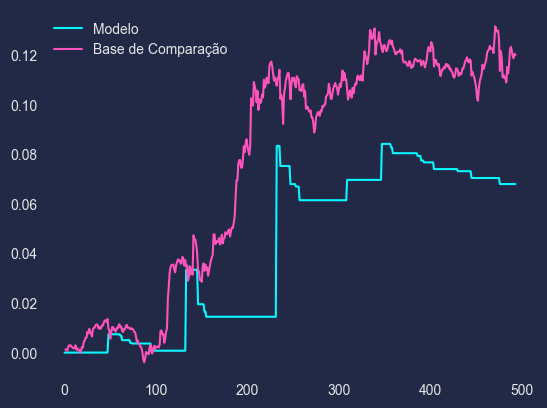

In [18]:
# Plotar resultados
dados_retorno_modelo.plot(label = "Modelo")
dados_retorno.plot(label = "Base de Comparação")
plt.legend()
plt.grid()
plt.show()

In [19]:
# Gerar comparativo em termos financeiros
quantia_inicial = 1000

valor_final_acumulado_base = quantia_inicial * (1 + dados_retorno.iloc[-1])
valor_final_acumulado_modelo = quantia_inicial * (1 + dados_retorno_modelo.iloc[-1])
quantidade_de_vendas = dados.posicao_obs.value_counts().venda
quantidade_vendas_positivas = len(dados[(dados.posicao_obs == 'venda') & (dados.retorno_modelo > 0)])
quantidade_vendas_negativas = len(dados[(dados.posicao_obs == 'venda') & (dados.retorno_modelo < 0)])

print(f"Valor final acumulado ao aplicar {quantia_inicial} reais na base de comparação: {valor_final_acumulado_base:.2f} reais")
print(f"Valor final acumulado ao aplicar {quantia_inicial} reais no modelo: {valor_final_acumulado_modelo:.2f} reais")
print(f"A estrategia rendeu {quantidade_de_vendas} vendas no total")
print(f"A estrategia rendeu {quantidade_vendas_positivas} vendas com retorno positivo")
print(f"A estrategia rendeu {quantidade_vendas_negativas} vendas com retorno negativo")

diferenca_percentual = ((valor_final_acumulado_modelo - valor_final_acumulado_base) / valor_final_acumulado_base) * 100

if valor_final_acumulado_modelo > valor_final_acumulado_base:
    print(f"O modelo teve um desempenho melhor que a base de comparação por {diferenca_percentual:.2f}%.")
else:
    print(f"A base de comparação teve um desempenho melhor que o modelo por {diferenca_percentual:.2f}%.") 

Valor final acumulado ao aplicar 1000 reais na base de comparação: 1120.22 reais
Valor final acumulado ao aplicar 1000 reais no modelo: 1068.04 reais
A estrategia rendeu 26 vendas no total
A estrategia rendeu 5 vendas com retorno positivo
A estrategia rendeu 21 vendas com retorno negativo
A base de comparação teve um desempenho melhor que o modelo por -4.66%.
